<a href="https://www.kaggle.com/code/harshigupta2006/kaggle-titanic-competition?scriptVersionId=299357263" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv
/kaggle/input/gender-submission/gender_submission1.csv
/kaggle/input/d/harshigupta2006/titanic/train.csv
/kaggle/input/d/harshigupta2006/titanic/test.csv
/kaggle/input/d/harshigupta2006/titanic/gender_submission.csv


READ FILES


In [2]:
gender=pd.read_csv("/kaggle/input/titanic/gender_submission.csv")


In [3]:
test=pd.read_csv("/kaggle/input/titanic/test.csv")

In [4]:
train=pd.read_csv("/kaggle/input/titanic/train.csv")

# Basic insights

gender file

In [5]:
gender.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [6]:
gender.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


In [7]:
gender.describe()

,PassengerId,Survived
count,418.000000,418.000000
mean,1100.500000,0.363636
std,120.810458,0.481622
min,892.000000,0.000000
25%,996.250000,0.000000
50%,1100.500000,0.000000
75%,1204.750000,1.000000
max,1309.000000,1.000000


In [8]:
gender.columns

Index(['PassengerId', 'Survived'], dtype='object')

In [9]:
gender.shape

(418, 2)

In [10]:
gender.tail()

,PassengerId,Survived
413,1305,0
414,1306,1
415,1307,0
416,1308,0
417,1309,0


# test file

In [11]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [12]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [13]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [14]:
test.shape

(418, 11)

In [15]:
test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [16]:
test.shape

(418, 11)

# train file insights

In [17]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [19]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [21]:
# pip install ydata-profiling

In [22]:
# from ydata_profiling import ProfileReport
# prof=ProfileReport(train)
# prof.to_file(output_file='output.html')

# Data Cleaning 

gender file contains no missing values

test file data cleaning

In [23]:
test['Age']=test['Age'].fillna(test['Age'].mean())
round(test['Age'],1)

0      34.5
1      47.0
2      62.0
3      27.0
4      22.0
       ... 
413    30.3
414    39.0
415    38.5
416    30.3
417    30.3
Name: Age, Length: 418, dtype: float64

In [24]:
test['Fare']=test['Fare'].fillna(test['Fare'].median())
test['Fare']

0        7.8292
1        7.0000
2        9.6875
3        8.6625
4       12.2875
         ...   
413      8.0500
414    108.9000
415      7.2500
416      8.0500
417     22.3583
Name: Fare, Length: 418, dtype: float64

In [25]:
test.loc[(test['Cabin'].isna()) & (test['SibSp']==0),'Cabin']='A89'
test.loc[(test['Cabin'].isna()) , 'Cabin']='E23'
test['Cabin']

0       A89
1       E23
2       A89
3       A89
4       E23
       ... 
413     A89
414    C105
415     A89
416     A89
417     E23
Name: Cabin, Length: 418, dtype: object

In [26]:
test['Embarked']=test['Embarked'].fillna(test['Embarked'].mode()[0])
test['Embarked']

0      Q
1      S
2      Q
3      S
4      S
      ..
413    S
414    C
415    S
416    S
417    C
Name: Embarked, Length: 418, dtype: object

train file data cleaning

In [27]:
train['Age']=train['Age'].fillna(train['Age'].mean())
round(train['Age'],1)

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    29.7
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [28]:
train.loc[(train['Cabin'].isna()) & (train['SibSp']==0) , 'Cabin']='A89'
train.loc[train['Cabin'].isna(), 'Cabin' ]= 'E23'
train['Cabin']

0       E23
1       C85
2       A89
3      C123
4       A89
       ... 
886     A89
887     B42
888     E23
889    C148
890     A89
Name: Cabin, Length: 891, dtype: object

In [29]:
train['Embarked']=train['Embarked'].fillna(train['Embarked'].mode()[0])
train['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

# Feature Engineering


In [30]:
test['Family']=test['SibSp'] + test['Parch'] +1
test['Family']

0      1
1      2
2      1
3      1
4      3
      ..
413    1
414    1
415    1
416    1
417    3
Name: Family, Length: 418, dtype: int64

In [31]:
train['Family']=train['SibSp'] + train['Parch'] +1
train['Family']

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: Family, Length: 891, dtype: int64

In [32]:
test['Name']

0                                  Kelly, Mr. James
1                  Wilkes, Mrs. James (Ellen Needs)
2                         Myles, Mr. Thomas Francis
3                                  Wirz, Mr. Albert
4      Hirvonen, Mrs. Alexander (Helga E Lindqvist)
                           ...                     
413                              Spector, Mr. Woolf
414                    Oliva y Ocana, Dona. Fermina
415                    Saether, Mr. Simon Sivertsen
416                             Ware, Mr. Frederick
417                        Peter, Master. Michael J
Name: Name, Length: 418, dtype: object

In [33]:
test[['Passenger_Name','Passenger_name']]=test['Name'].str.split(", ",expand=True)
test[['Passenger_Name','Passenger_name']]

,Passenger_Name,Passenger_name
0,Kelly,Mr. James
1,Wilkes,Mrs. James (Ellen Needs)
2,Myles,Mr. Thomas Francis
3,Wirz,Mr. Albert
4,Hirvonen,Mrs. Alexander (Helga E Lindqvist)
...,...,...
413,Spector,Mr. Woolf
414,Oliva y Ocana,Dona. Fermina
415,Saether,Mr. Simon Sivertsen
416,Ware,Mr. Frederick


In [34]:
train[['Passenger_Name','Passenger_name']]=train['Name'].str.split(", ",expand=True)
train[['Passenger_Name','Passenger_name']]

,Passenger_Name,Passenger_name
0,Braund,Mr. Owen Harris
1,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,Heikkinen,Miss. Laina
3,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,Allen,Mr. William Henry
...,...,...
886,Montvila,Rev. Juozas
887,Graham,Miss. Margaret Edith
888,Johnston,"Miss. Catherine Helen ""Carrie"""
889,Behr,Mr. Karl Howell


In [35]:
train.isnull().sum()

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin             0
Embarked          0
Family            0
Passenger_Name    0
Passenger_name    0
dtype: int64

In [36]:
train[['Title', 'Passenger_Name']] = train['Passenger_name'].str.split('. ', expand=True, n=1)
train[['Title','Passenger_Name']]

,Title,Passenger_Name
0,Mr,Owen Harris
1,Mrs,John Bradley (Florence Briggs Thayer)
2,Miss,Laina
3,Mrs,Jacques Heath (Lily May Peel)
4,Mr,William Henry
...,...,...
886,Rev,Juozas
887,Miss,Margaret Edith
888,Miss,"Catherine Helen ""Carrie"""
889,Mr,Karl Howell


**Standardization**
**one hot encoding**

In [37]:
train.shape

(891, 16)

In [38]:
# train.drop(columns=['Name','Ticket','Cabin','Passenger_Name','Passenger_name','Title'],inplace=True)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family,Passenger_Name,Passenger_name,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,E23,S,2,Owen Harris,Mr. Owen Harris,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,John Bradley (Florence Briggs Thayer),Mrs. John Bradley (Florence Briggs Thayer),Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,A89,S,1,Laina,Miss. Laina,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,Jacques Heath (Lily May Peel),Mrs. Jacques Heath (Lily May Peel),Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,A89,S,1,William Henry,Mr. William Henry,Mr


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.tree import DecisionTreeClassifier 
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy import stats

In [46]:
#train test model
X_train,X_test,y_train,y_test=train_test_split(train.drop(columns=['Passenger_Name'	,'Passenger_name',	'Title', 'Name','Ticket','Cabin','Survived']),
                                               train['Survived'],test_size=0.2,random_state=42)

In [47]:
#impute missing values
# trf1=ColumnTransformer([('Impute_age',SimpleImputer(),[4])],remainder='passthrough')

In [48]:
# one hot encoding
trf2=ColumnTransformer( [('Impute_age',SimpleImputer(),['Age']),
                         ('sex_ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Sex']),
        ('embarked_ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Embarked']),
                        ],remainder='passthrough')


In [49]:
# scaling 
trf3= ColumnTransformer([('scale',MinMaxScaler(),slice(0,10))],remainder='passthrough')

In [50]:
#feature selection
trf4=SelectKBest(score_func=chi2,k=8)

In [51]:
#train the model
trf5=DecisionTreeClassifier()

In [52]:
pipe=Pipeline([('trf2',trf2),('trf4',trf4),('trf5',trf5)])

In [53]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Impute_age', SimpleImputer(),
                                                  ['Age']),
                                                 ('sex_ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Sex']),
                                                 ('embarked_ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Embarked'])])),
                ('trf4',
                 SelectKBest(k=8,
                             score_func=<function chi2 at 0x7d37821d7380>)),
                ('trf5', DecisionTreeClassifier())])

In [54]:
X_train_transformed=pipe.named_steps['trf2'].transform(X_train)

In [55]:
feature_names=pipe.named_steps['trf2'].get_feature_names_out()

In [56]:
X_train_df=pd.DataFrame(X_train_transformed,columns=feature_names,index=X_train.index)

In [57]:
X_train_df.head()

,Impute_age__Age,sex_ohe__Sex_female,sex_ohe__Sex_male,embarked_ohe__Embarked_C,embarked_ohe__Embarked_Q,embarked_ohe__Embarked_S,remainder__PassengerId,remainder__Pclass,remainder__SibSp,remainder__Parch,remainder__Fare,remainder__Family
331,45.5,0.0,1.0,0.0,0.0,1.0,332.0,1.0,0.0,0.0,28.5000,1.0
733,23.0,0.0,1.0,0.0,0.0,1.0,734.0,2.0,0.0,0.0,13.0000,1.0
382,32.0,0.0,1.0,0.0,0.0,1.0,383.0,3.0,0.0,0.0,7.9250,1.0
704,26.0,0.0,1.0,0.0,0.0,1.0,705.0,3.0,1.0,0.0,7.8542,2.0
813,6.0,1.0,0.0,0.0,0.0,1.0,814.0,3.0,4.0,2.0,31.2750,7.0


**Function transformer**

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


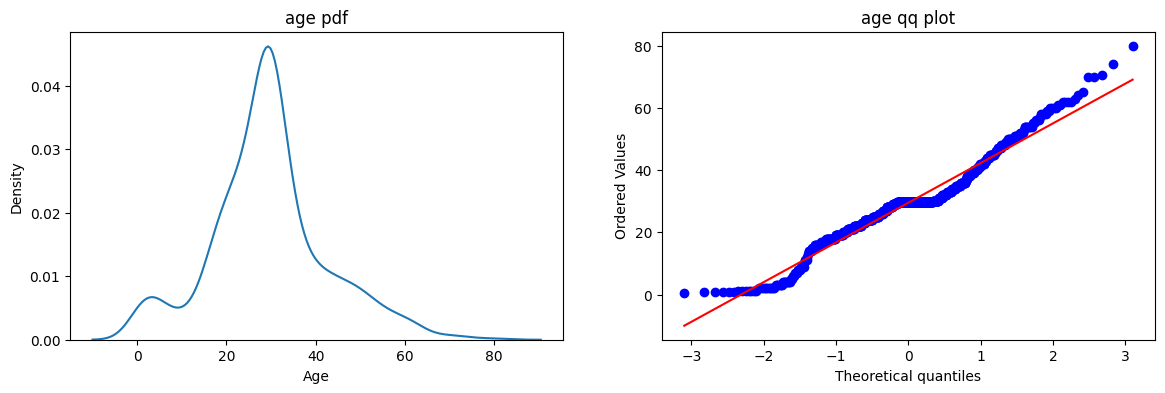

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.kdeplot(X_train['Age'])
plt.title('age pdf')

plt.subplot(122)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('age qq plot')
plt.show()

In [59]:
y_predict=pipe.predict(X_test)
print("accuracy of decison tree classifier is:", accuracy_score(y_test,y_predict))


accuracy of decison tree classifier is: 0.7318435754189944


In [60]:
lr=LogisticRegression()

pipe_lr=Pipeline([('trf2',trf2),('trf4',trf4),('lr',lr)])
pipe_lr.fit(X_train,y_train)

y_pred=pipe_lr.predict(X_test)


print("acc lr:", accuracy_score(y_test,y_pred))


acc lr: 0.8044692737430168


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [61]:
ft=FunctionTransformer(func=np.log1p)

pipe_ft=Pipeline([('trf2',trf2),('ft',ft),('trf4',trf4),('trf5',trf5)])
X_train_transformed=pipe_ft.fit(X_train, y_train)
y_pred_ft = pipe_ft.predict(X_test)

print("accuracy decision tree classifier:", accuracy_score(y_test,y_pred_ft))

pipe_ft_lr=Pipeline([('trf2',trf2),('ft',ft),('trf4',trf4),('lr',lr)])
X_train_transformed=pipe_ft_lr.fit(X_train,y_train)
y_predict_lr=pipe_ft_lr.predict(X_test)

print("accuracy logistic regression:",accuracy_score(y_test,y_predict_lr))

accuracy decision tree classifier: 0.770949720670391
accuracy logistic regression: 0.7877094972067039


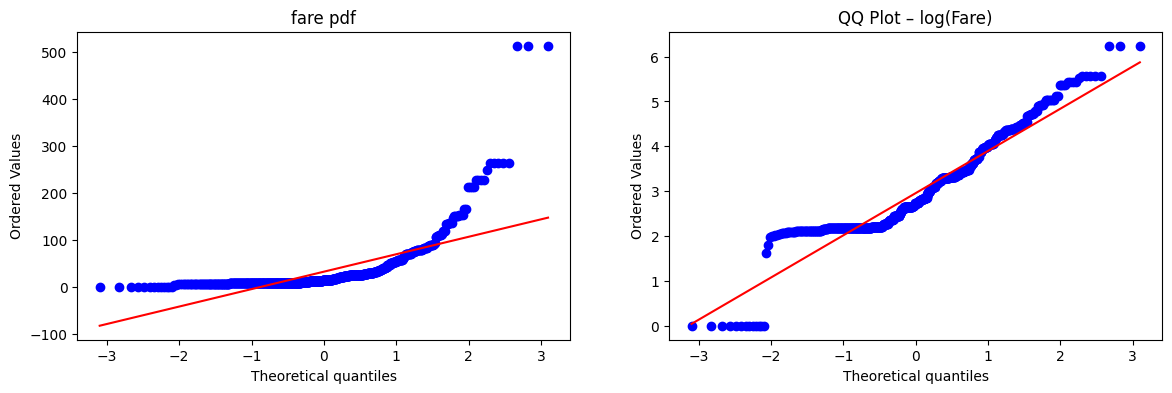

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'],dist='norm', plot=plt)
plt.title('fare pdf')

plt.subplot(122)
# stats.probplot(X_train_transformed['Age'],dist='norm',plot=plt)
# plt.title('age qq plot')

stats.probplot(np.log1p(X_train['Fare']), dist='norm', plot=plt)
plt.title('QQ Plot – log(Fare)')
plt.show()


**handling mixed data**

In [63]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PassengerId     891 non-null    int64  
 1   Survived        891 non-null    int64  
 2   Pclass          891 non-null    int64  
 3   Name            891 non-null    object 
 4   Sex             891 non-null    object 
 5   Age             891 non-null    float64
 6   SibSp           891 non-null    int64  
 7   Parch           891 non-null    int64  
 8   Ticket          891 non-null    object 
 9   Fare            891 non-null    float64
 10  Cabin           891 non-null    object 
 11  Embarked        891 non-null    object 
 12  Family          891 non-null    int64  
 13  Passenger_Name  891 non-null    object 
 14  Passenger_name  891 non-null    object 
 15  Title           891 non-null    object 
dtypes: float64(2), int64(6), object(8)
memory usage: 111.5+ KB


In [64]:
train['cabin_categorical']=train['Cabin'].str[0]
train['cabin_categorical']=train['cabin_categorical'].fillna('missing')
train['cabin_numerical']=train['Cabin'].str.extract('(\d+)')

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family,Passenger_Name,Passenger_name,Title,cabin_categorical,cabin_numerical
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,E23,S,2,Owen Harris,Mr. Owen Harris,Mr,E,23
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,John Bradley (Florence Briggs Thayer),Mrs. John Bradley (Florence Briggs Thayer),Mrs,C,85
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,A89,S,1,Laina,Miss. Laina,Miss,A,89
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,Jacques Heath (Lily May Peel),Mrs. Jacques Heath (Lily May Peel),Mrs,C,123
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,A89,S,1,William Henry,Mr. William Henry,Mr,A,89



# Exploratory Data Analysis

In [65]:
survived_ratio=train.groupby('Sex')['Survived'].count()
survived_ratio

Sex
female    314
male      577
Name: Survived, dtype: int64

In [66]:
survived_ratio1=train.groupby('Sex')['Survived'].value_counts(normalize=True)
survived_ratio1*100

Sex     Survived
female  1           74.203822
        0           25.796178
male    0           81.109185
        1           18.890815
Name: proportion, dtype: float64

In [67]:
pd.crosstab(train['Sex'],train['Survived'], normalize='index')

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


In [68]:
survived_ratio2=train.groupby('Sex')['Survived'].mean()
survived_ratio2 

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [69]:
#not survived

survived=train[train['Survived']==0]
not_survived_ratio=survived.groupby('Sex')['Survived'].count()
not_survived_ratio 

Sex
female     81
male      468
Name: Survived, dtype: int64

In [70]:
class_ratio=train.groupby('Pclass')['Survived'].value_counts()
class_ratio

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

In [71]:
class_ratio2=train.groupby('Pclass')['Survived'].count()
class_ratio2

Pclass
1    216
2    184
3    491
Name: Survived, dtype: int64

In [72]:
class_ratio1=train.groupby('Pclass')['Survived'].mean()
class_ratio1*100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [73]:
class_sex_ratio=train.groupby('Sex')['Pclass'].value_counts(ascending=False)
class_sex_ratio

Sex     Pclass
female  3         144
        1          94
        2          76
male    3         347
        1         122
        2         108
Name: count, dtype: int64

In [74]:
pd.crosstab(train['Pclass'],train['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [75]:
class_sex_ratio1=train.groupby('Sex')['Pclass'].mean()
class_sex_ratio1

Sex
female    2.159236
male      2.389948
Name: Pclass, dtype: float64

In [76]:
for_3class=train[train['Pclass']==3]
class_sex_ratio2=for_3class.groupby('Sex')['Pclass'].count()
class_sex_ratio2 / survived_ratio *100

Sex
female    45.859873
male      60.138648
dtype: float64

In [77]:
cabin_survived=train.groupby('Cabin')['Survived'].value_counts().sort_values(ascending=False)
cabin_survived

Cabin    Survived
A89      0           349
         1           133
E23      0           132
         1            73
B96 B98  1             4
                    ... 
C123     1             1
C128     0             1
C148     1             1
C2       0             1
T        0             1
Name: count, Length: 167, dtype: int64

# Data Visualization

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

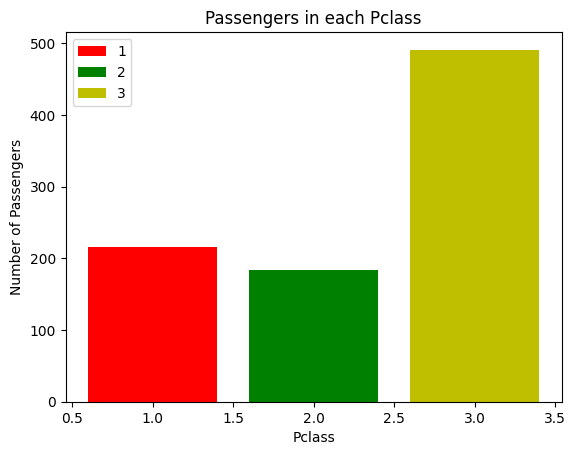

In [79]:
plt.bar(class_ratio2.index,class_ratio2.values,label=[1,2,3],color=['r','g','y'])
plt.title("Passengers in each Pclass")
plt.xlabel("Pclass")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

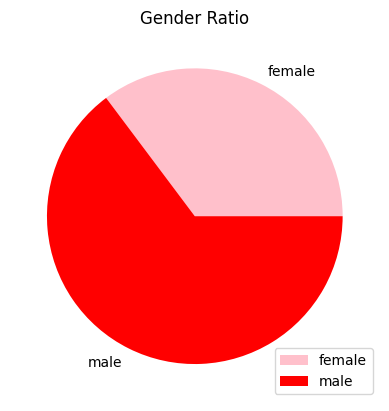

In [80]:
plt.pie(survived_ratio,labels=survived_ratio.index,colors=['pink','red'])
plt.legend(loc='lower right')
plt.title("Gender Ratio")
plt.show()

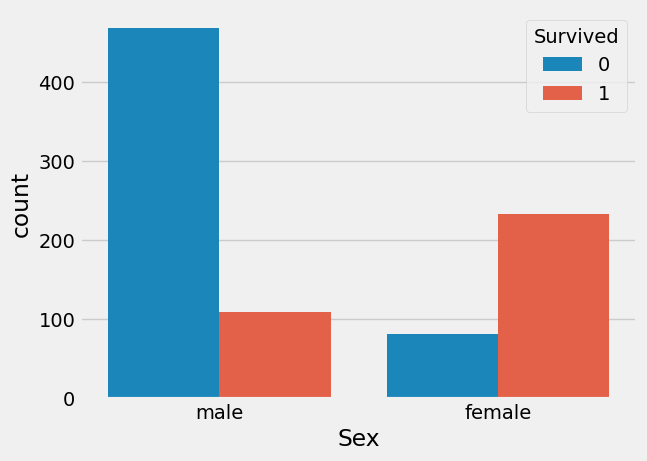

In [81]:
plt.style.use('fivethirtyeight')
sns.countplot(data=train,x='Sex',hue='Survived')
plt.show()

In [82]:
count_survived_people=train['Survived'].value_counts()
count_survived_people

Survived
0    549
1    342
Name: count, dtype: int64

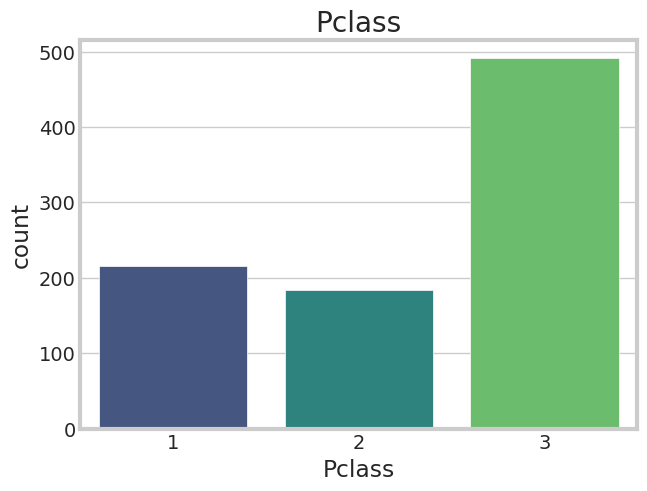

In [83]:
#pclass
sns.set_style('whitegrid')
sns.countplot(x='Pclass',data=train,palette='viridis')
plt.title("Pclass")
plt.show()

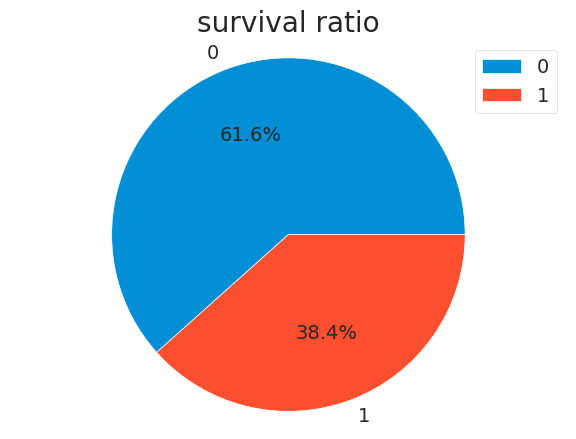

In [84]:
#survived 
plt.pie(count_survived_people,labels=count_survived_people.index,autopct='%1.1f%%',explode=[0,0])
plt.axis('equal')
plt.title("survival ratio")
plt.legend()
plt.show()

/tmp/ipykernel_47/577671157.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'],bins=10,hist=True,kde=True)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


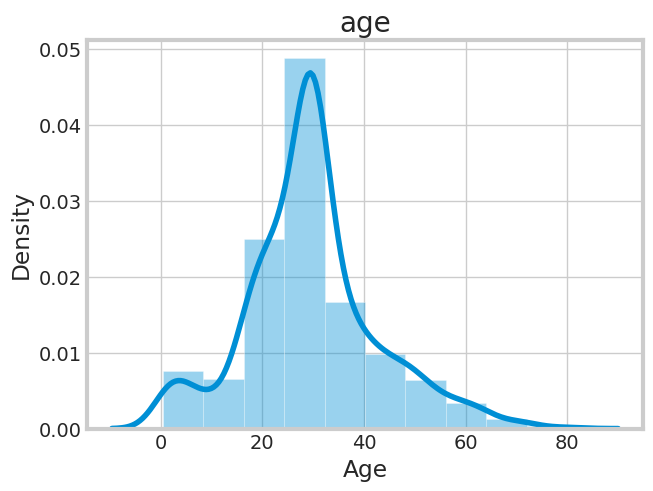

In [85]:
sns.distplot(train['Age'],bins=10,hist=True,kde=True)
plt.title("age")
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


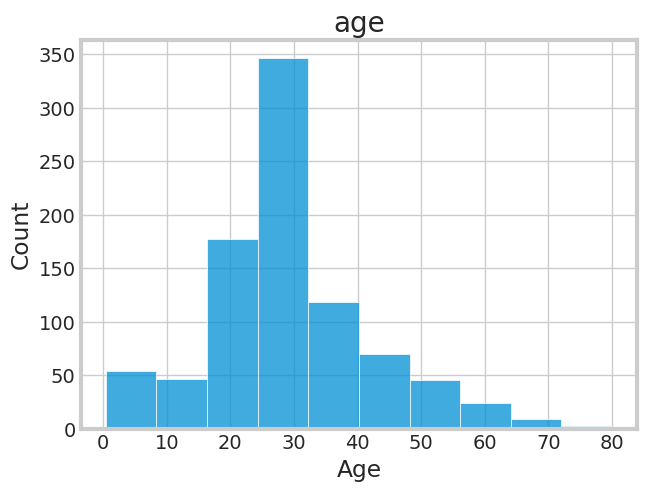

In [86]:
sns.histplot(data=train,x='Age',bins=10)
plt.title('age')
plt.show()

/tmp/ipykernel_47/1176997821.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Fare'],bins=20,hist=True,kde=True)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


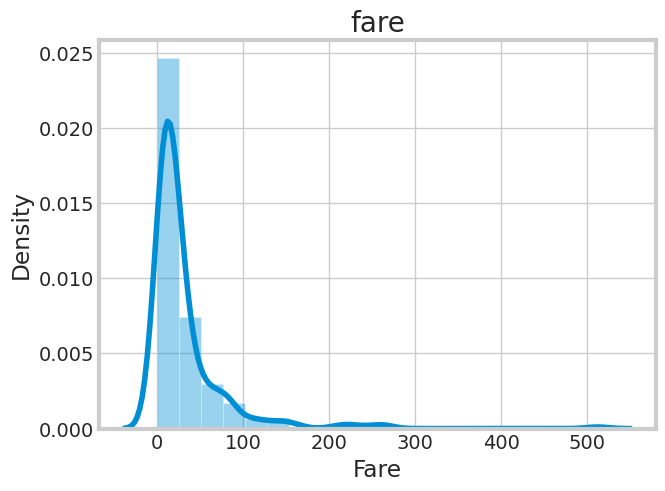

In [87]:
sns.distplot(train['Fare'],bins=20,hist=True,kde=True)
plt.title("fare")
plt.show()

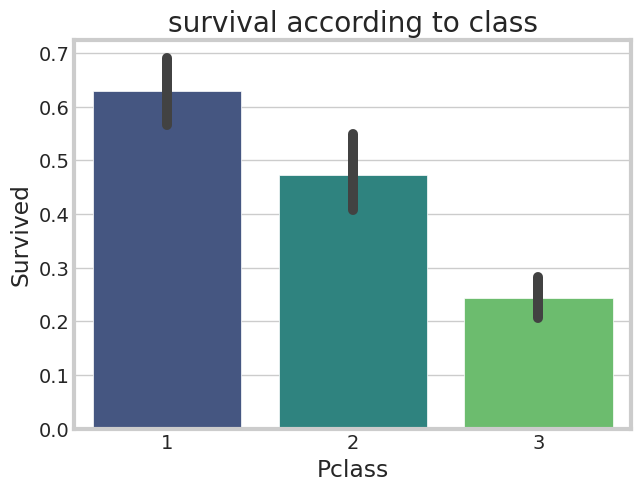

In [88]:
sns.barplot(x='Pclass',data=train,y='Survived',palette='viridis')
plt.title("survival according to class")
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


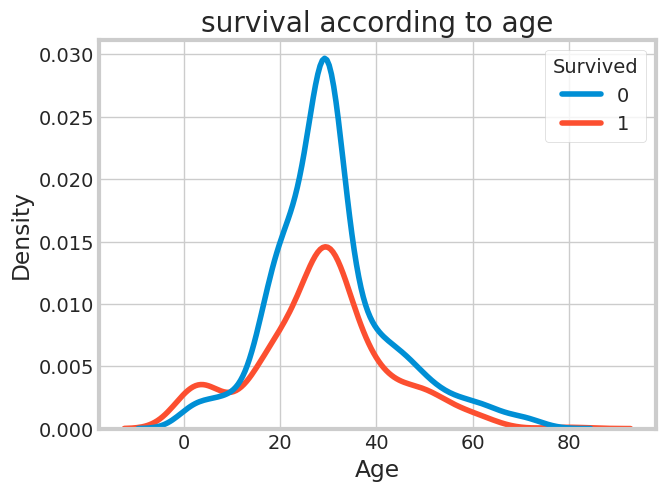

In [89]:
sns.kdeplot(x='Age',hue='Survived',data=train)
plt.title("survival according to age")
plt.show()

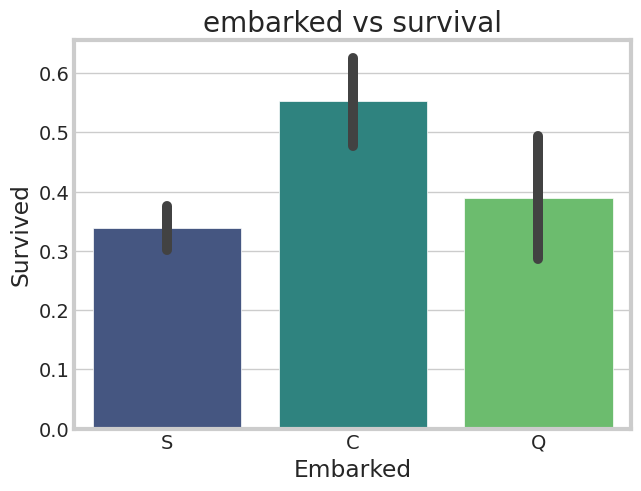

In [90]:
sns.barplot(x='Embarked',y='Survived',data=train,palette='viridis')
plt.title("embarked vs survival")
plt.show()

In [91]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Family',
       'Passenger_Name', 'Passenger_name', 'Title', 'cabin_categorical',
       'cabin_numerical'],
      dtype='object')

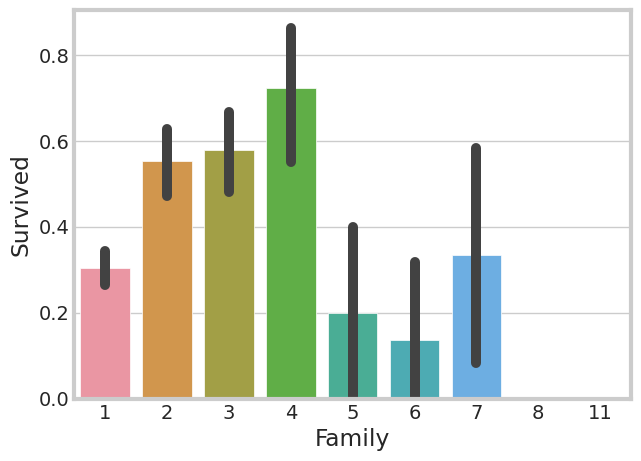

In [92]:
sns.barplot(x='Family',data=train,y='Survived')
plt.show()

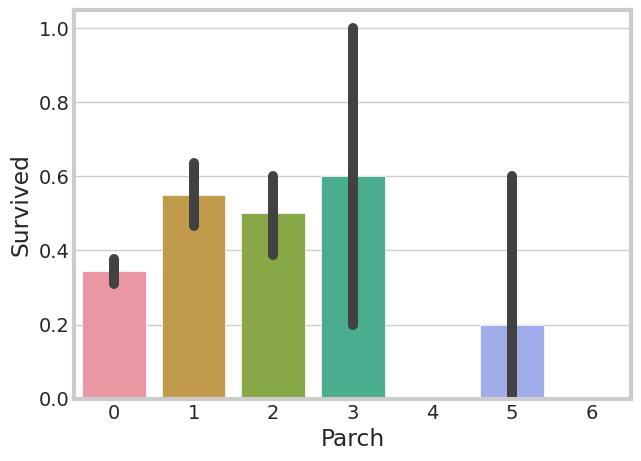

In [93]:
sns.barplot(x='Parch',y='Survived',data=train)
plt.show()

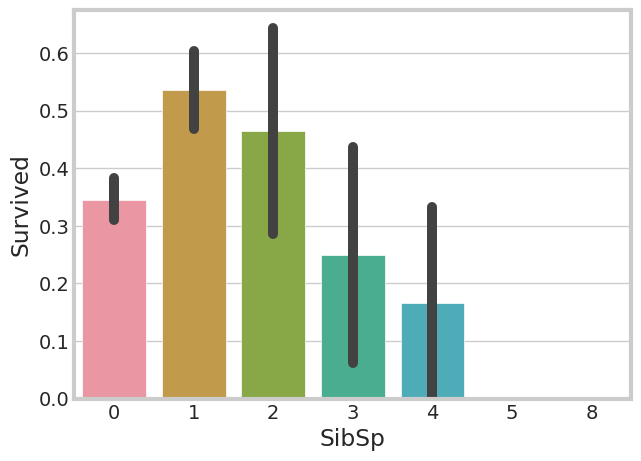

In [94]:
sns.barplot(x='SibSp',y='Survived',data=train)
plt.show()

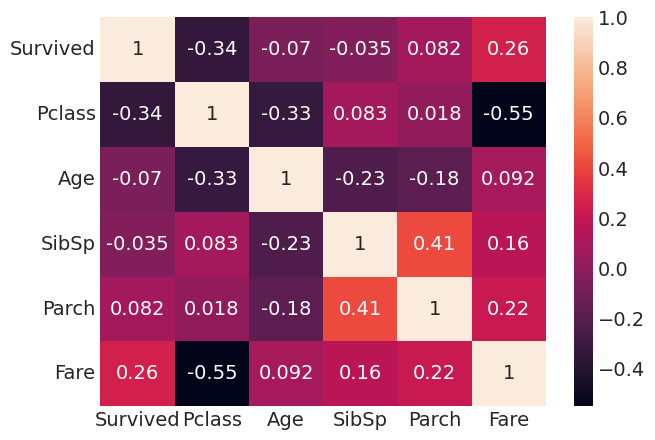

In [95]:
correlation=train[['Survived','Pclass','Age','SibSp','Parch','Fare',]].corr()
sns.heatmap(correlation,annot=True)
plt.show()

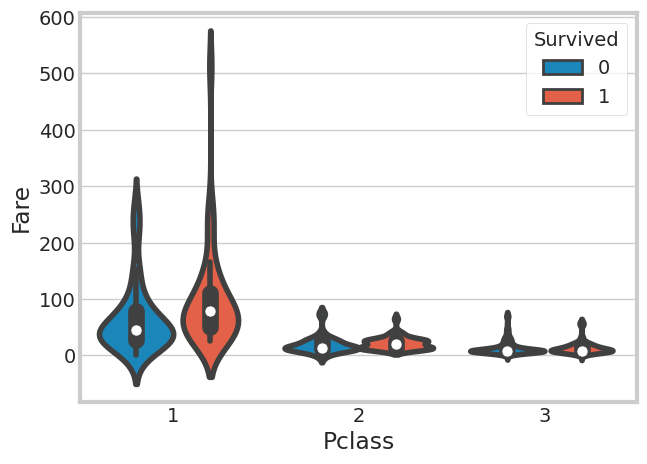

In [96]:
sns.violinplot(y='Fare',x='Pclass',hue='Survived',data=train)
plt.show()

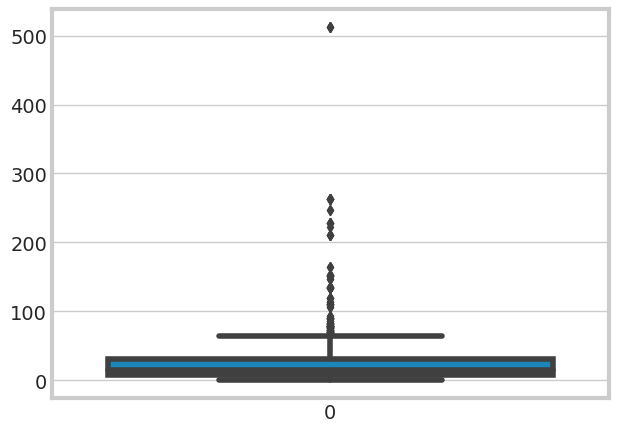

In [97]:
sns.boxplot(train['Fare'])
plt.show()

# Rule based Analysis

In [98]:
def rule_based(train):
    if train['Sex']=='female':
        return 1
    
    elif train['Pclass']==1:
        return 1
    
    elif train['Age']>=20 and train['Age']<40:
        return 1
    
    else:
        return 0
    

test['Survived']=test.apply(rule_based,axis=1)

In [99]:
test['Survived']

0      1
1      1
2      0
3      1
4      1
      ..
413    1
414    1
415    1
416    1
417    1
Name: Survived, Length: 418, dtype: int64

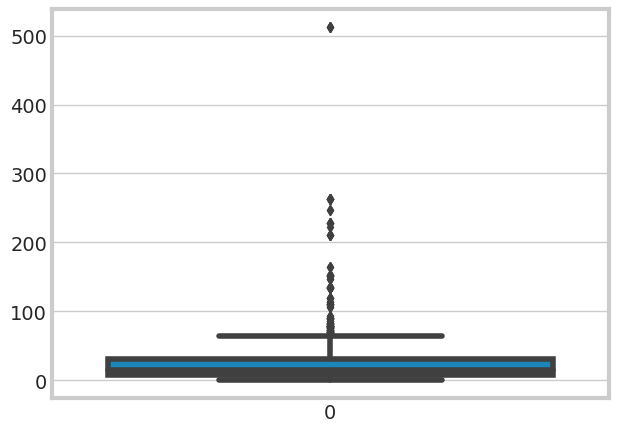

In [100]:
sns.boxplot(train['Fare'])
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


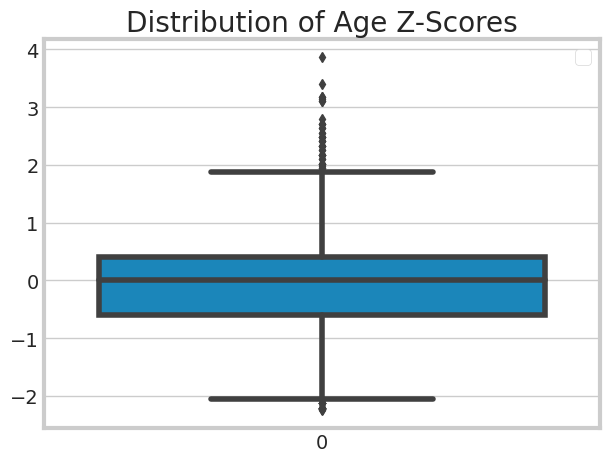

In [101]:
age_mean = train['Age'].mean()
age_std = train['Age'].std()

train['Age_Zscore'] = (train['Age'] - age_mean) / age_std

train['Is_Outlier_Zscore'] = (train['Age_Zscore'] > 3) | (train['Age_Zscore'] < -3)

sns.boxplot(train['Age_Zscore'])
plt.title("Distribution of Age Z-Scores")
plt.legend()
plt.show()

In [102]:
train['Age_Zscore']

0     -0.592148
1      0.638430
2     -0.284503
3      0.407697
4      0.407697
         ...   
886   -0.207592
887   -0.822881
888    0.000000
889   -0.284503
890    0.176964
Name: Age_Zscore, Length: 891, dtype: float64

In [103]:
fare_mean = train['Fare'].mean()
fare_std = train['Fare'].std()

train['Fare_Zscore'] = (train['Fare'] - fare_mean) / fare_std
train['Fare_Zscore'].describe()

count    8.910000e+02
mean     1.993666e-18
std      1.000000e+00
min     -6.480577e-01
25%     -4.888737e-01
50%     -3.571902e-01
75%     -2.423274e-02
max      9.661740e+00
Name: Fare_Zscore, dtype: float64

# Gender Submission File Creation

In [104]:
gender = pd.DataFrame({
    "PassengerId": test['PassengerId'],
    "Survived": test['Survived']
})


In [105]:
file_path="/kaggle/working/gender-submission.csv"
gender.to_csv(file_path,index=False)

print("file created")

file created
